In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import textwrap

from transformers import AutoModelForCausalLM,GPT2Tokenizer
# huggingface libraries
from datasets import load_dataset, DatasetDict

In [2]:
# !pip install datasets
# !pip install "protobuf<6.0.0"

In [3]:
# load pretrained GPT-2 model and tokenizer
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2')
# gpt2 = AutoModelForCausalLM.from_pretrained('gpt2-large')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [4]:
# hyperparameters
seq_len    = 256 # max sequence length
batch_size =  32

# use GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [5]:
train_ds = load_dataset("albertleigh/az-logic-apps-dataset", data_files="train/training_dataset_v1.parquet")

In [6]:
train_ds['train'][0]

{'natural_language': 'Get the current item in the For_each_ControlArea loop.',
 'expression': "@items('For_each_ControlArea')",
 'functions': ['items'],
 'context': 'actions.For_each_Data_Sources_from_AADSCA.actions.Switch_CollectedBy.cases.Case_Logic_App.actions.For_each_ControlArea.actions.Microsoft_Graph_Call_for_AAD_SCA_Control.inputs.uri',
 'complexity': {'function_count': 1, 'nesting_level': 1},
 'metadata': {'repo_stars': 2447,
  'source_file': 'config/deploy/AADSCA-LogicApp.arm.json',
  'source_repo': 'Cloud-Architekt/AzureAD-Attack-Defense',
  'source_url': 'https://github.com/Cloud-Architekt/AzureAD-Attack-Defense/blob/e61003f199989ffb8feba8fefa040f3686078714/config/deploy/AADSCA-LogicApp.arm.json'},
 'quality_score': 0.8999999999999999,
 'nl_updated_at': '2026-01-04T16:50:50.311430'}

In [7]:
sampleLengths = np.zeros((len(train_ds['train']),2))

for i in range(sampleLengths.shape[0]):

  sampleLengths[i,0] = len(tokenizer.encode(train_ds['train'][i]['natural_language']))
  sampleLengths[i,1] = len(tokenizer.encode(train_ds['train'][i]['expression']))

# Filter out samples where the combined length is greater than seq_len
# The condition is sampleLengths[:,0] + sampleLengths[:,1] <= seq_len
sampleLengths = sampleLengths[np.sum(sampleLengths, axis=1) <= seq_len]

In [8]:
def filter_by_length(example):
  nl_len = len(tokenizer.encode(example['natural_language']))
  exp_len = len(tokenizer.encode(example['expression']))
  return (nl_len + exp_len) <= seq_len

# Apply the filter to the 'train' split of the dataset
train_ds['train'] = train_ds['train'].filter(filter_by_length)

print(f"New number of samples in train_ds['train']: {len(train_ds['train'])}")

New number of samples in train_ds['train']: 14931


In [9]:
train_ds

DatasetDict({
    train: Dataset({
        features: ['natural_language', 'expression', 'functions', 'context', 'complexity', 'metadata', 'quality_score', 'nl_updated_at'],
        num_rows: 14931
    })
})

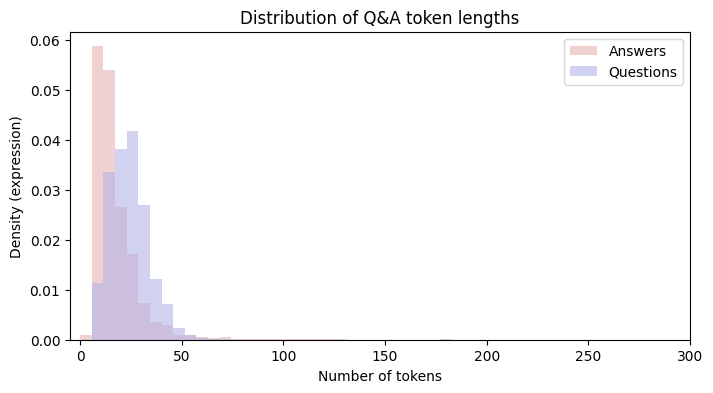

In [10]:
binedges = np.linspace(0,400,71)
yQ,xQ = np.histogram(sampleLengths[:,0],bins=binedges,density=True)
yA,xA = np.histogram(sampleLengths[:,1],bins=binedges,density=True)

plt.figure(figsize=(8,4))

# Use plt.stairs for a cleaner look when plotting pre-computed bin counts/density
plt.stairs(yA, xA, fill=True, color=[.9,.7,.7], alpha=0.6, label='Answers', edgecolor='k')
plt.stairs(yQ, xQ, fill=True, color=[.7,.7,.9], alpha=0.6, label='Questions', edgecolor='k')

plt.gca().set(xlim=[-5, 300],
             xlabel='Number of tokens',
             ylabel='Density (expression)',
             title='Distribution of Q&A token lengths')
plt.legend()
plt.show()

In [11]:
np.max(np.sum(sampleLengths, axis=1))

np.float64(243.0)

In [12]:
len(sampleLengths)

14931

In [13]:
# initializing (just using the first 10k data samples)
trainTokens = torch.full((len(sampleLengths),seq_len),tokenizer.pad_token_id)

for idx in range(trainTokens.shape[0]):

  # construct the token sequence
  txt = f"QUESTION: {train_ds['train'][idx]['natural_language']} ANSWER: {train_ds['train'][idx]['expression']}."
  tokz = tokenizer.encode(txt,add_special_tokens=True)

  # insert this sequence into the data matrix, truncating when necessary
  endOfSeq = min(seq_len,len(tokz))
  trainTokens[idx,:endOfSeq] = torch.tensor(tokz[:endOfSeq])

In [14]:
num_total_samples = trainTokens.shape[0]
num_test_samples = int(0.1 * num_total_samples)

# Generate random permutations of indices
shuffled_indices = torch.randperm(num_total_samples)

# Split indices into training and test
test_indices = shuffled_indices[:num_test_samples]
train_indices = shuffled_indices[num_test_samples:]

# Create testTokens and update trainTokens
testTokens = trainTokens[test_indices]
trainTokens = trainTokens[train_indices]

print(f"Original number of samples: {num_total_samples}")
print(f"Number of samples in new trainTokens: {trainTokens.shape[0]}")
print(f"Number of samples in testTokens: {testTokens.shape[0]}")

Original number of samples: 14931
Number of samples in new trainTokens: 13438
Number of samples in testTokens: 1493


In [15]:
# attention mask
attn_mask = (trainTokens[0] != tokenizer.pad_token_id).long()

print(f'Training tokens:\n{trainTokens[0]}\n')
print(f'Attention mask:\n{attn_mask}')

Training tokens:
tensor([35780,  2849,    25,  3497,   262,  1767,  5072,   422,   262,   564,
          250, 10044,   325,    62,  9171, 10466,    62, 31077,   447,   251,
         2223,    11,  1312,    13,    68,  1539,   262, 44267, 20731,  1366,
           11,   973,   994,   355,   262,  4947,   284, 11629,   378,   625,
          287,   262,  9052,    13,  3537, 17887,  1137,    25,  2488,  2618,
        10786, 10044,   325,    62,  9171, 10466,    62, 31077, 27691, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 5025

In [16]:
# check a random batch
ix = np.random.randint(0,trainTokens[0].shape,batch_size)
X  = trainTokens[ix]
attn_mask = (X != tokenizer.pad_token_id).long()


print(f'Size of batch: {X.shape}')
print(f'Size of attention mask: {attn_mask.shape}\n')

print('Some examples:')
for t in range(5):
  print(f'*** Example: \n',textwrap.fill(tokenizer.decode(X[t]),123),'\n')

Size of batch: torch.Size([32, 256])
Size of attention mask: torch.Size([32, 256])

Some examples:
*** Example: 
 QUESTION: Retrieve the Investment_Promotion__c value from the current item in the For_each_4 loop. ANSWER: @{items('For_eac
h_4')?['Investment_Promotion__c']}.<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftex
t|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|e
ndoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endofte
xt|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|
endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoft
ext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><
|endoftext|><|endo

In [17]:
aveAM = (trainTokens == tokenizer.pad_token_id).sum()/torch.numel(trainTokens)
print(f'{aveAM*100:5.2f}% of TRAIN token positions are EOS.')

aveAM = (testTokens == tokenizer.pad_token_id).sum()/torch.numel(testTokens)
print(f'{aveAM*100:5.2f}% of TEST token positions are EOS.')

81.04% of TRAIN token positions are EOS.
81.10% of TEST token positions are EOS.


### Fine-tune the model

In [18]:
# move the model to the GPU
gpt2 = gpt2.to(device)

# create the optimizer functions
optimizer = torch.optim.AdamW(gpt2.parameters(), lr=1e-4, weight_decay=.01)

In [19]:
# initialize tainning and losses
num_samples = 1234
train_loss = np.zeros(num_samples)
test_loss  = np.zeros(num_samples)
iteration = 0

In [30]:
iteration = 1
train_loss = np.concatenate((train_loss, np.zeros(num_samples)))
test_loss = np.concatenate((test_loss, np.zeros(num_samples)))

In [31]:
for sampli in range(iteration * num_samples, (iteration+1)*num_samples):

  # get a batch of data and create a mask
  ix = np.random.randint(0,trainTokens[0].shape,batch_size)
  X  = trainTokens[ix]
  attn_mask = (X != tokenizer.pad_token_id).long()

  # move data to GPU
  attn_mask = attn_mask.to(device)
  X = X.to(device)

  # forward pass (Hugging Face shifts X internally to get y)
  gpt2.zero_grad()
  outputs = gpt2(X,labels=X,attention_mask=attn_mask)
  loss = outputs.loss

  # backprop
  loss.backward()
  optimizer.step()

  # store the per-sample loss
  train_loss[sampli] = loss.item()

  # test and update progress display
  if sampli%77==0:

    # get a batch of data and create a mask
    ix = np.random.randint(0,testTokens[0].shape,batch_size)
    X  = testTokens[ix]
    attn_mask = (X != tokenizer.pad_token_id).long()

    # move data to GPU
    attn_mask, X = attn_mask.to(device), X.to(device)

    # forward pass and get loss
    with torch.no_grad():
      gpt2.eval()
      outputs = gpt2(X,labels=X,attention_mask=attn_mask)
      test_loss[sampli] = outputs.loss.item()
    gpt2.train()

    # report progress
    print(f'Sample {sampli:4}/{num_samples*iteration}, train/test loss: {train_loss[sampli]:.4f}/{test_loss[sampli]:.4f}')

iteration+=1
train_loss = np.concatenate((train_loss, np.zeros(num_samples)))
test_loss = np.concatenate((test_loss, np.zeros(num_samples)))

Sample 1309/1234, train/test loss: 0.0240/0.4273
Sample 1386/1234, train/test loss: 0.0256/0.5003
Sample 1463/1234, train/test loss: 0.0241/0.3216
Sample 1540/1234, train/test loss: 0.0255/0.4638
Sample 1617/1234, train/test loss: 0.0249/0.4374
Sample 1694/1234, train/test loss: 0.0232/0.4096
Sample 1771/1234, train/test loss: 0.0244/0.3819
Sample 1848/1234, train/test loss: 0.0256/0.4711
Sample 1925/1234, train/test loss: 0.0254/0.4207
Sample 2002/1234, train/test loss: 0.0249/0.4699
Sample 2079/1234, train/test loss: 0.0236/0.4960
Sample 2156/1234, train/test loss: 0.0236/0.6253
Sample 2233/1234, train/test loss: 0.0255/0.4942
Sample 2310/1234, train/test loss: 0.0243/0.5635
Sample 2387/1234, train/test loss: 0.0243/0.4705
Sample 2464/1234, train/test loss: 0.0239/0.4891


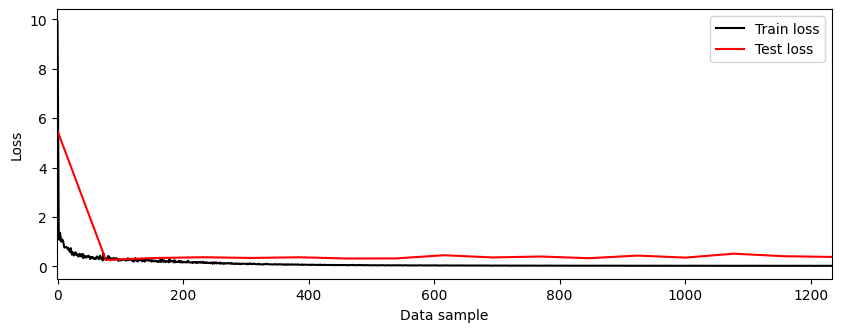

In [32]:
# plot the losses
plt.figure(figsize=(10,3.5))
plt.plot(train_loss,'k',label='Train loss')
x4test = np.where(test_loss)[0]
plt.plot(x4test,test_loss[x4test],'r',label='Test loss')

plt.legend()
plt.gca().set(xlabel='Data sample',ylabel='Loss',xlim=[-1,num_samples])
plt.show()

In [28]:
# Qualtative assessment
# prompt = 'QUESTION: Get the Name property from the first item in the FilterContributionTypes action’s output. If no items are returned, this yields null.'
prompt = 'QUESTION: Get the value of the variable ContributionsAdded.'
in2gpt = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)

output = gpt2.generate(in2gpt,max_length=100,pad_token_id=50256,do_sample=True)
print(tokenizer.decode(in2gpt[0].cpu()),'\n')
print(textwrap.fill(tokenizer.decode(output[0][len(in2gpt[0]):]),60))

QUESTION: Get the value of the variable ContributionsAdded. 

 ANSWER: @{variables('ContributionsAdded')}.<|endoftext|>


In [23]:
# Define the directory where you want to save the model
save_directory = "./azLgcExpGpt_HF"

# Save the model and tokenizer
gpt2.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved to: {save_directory}")

Model and tokenizer saved to: ./azLgcExpGpt_HF


In [24]:
# Example of how to load the model back
# loaded_model = AutoModelForCausalLM.from_pretrained(save_directory)
# loaded_tokenizer = GPT2Tokenizer.from_pretrained(save_directory)

# print("Model and tokenizer loaded successfully from local files.")

In [25]:
# Option 3: zip using unix
!zip -r azLgcExpGpt_HF.zip ./azLgcExpGpt_HF

  adding: azLgcExpGpt_HF/ (stored 0%)
  adding: azLgcExpGpt_HF/config.json (deflated 51%)
  adding: azLgcExpGpt_HF/model.safetensors (deflated 7%)
  adding: azLgcExpGpt_HF/generation_config.json (deflated 24%)
  adding: azLgcExpGpt_HF/vocab.json (deflated 68%)
  adding: azLgcExpGpt_HF/merges.txt (deflated 53%)
  adding: azLgcExpGpt_HF/tokenizer_config.json (deflated 56%)
  adding: azLgcExpGpt_HF/special_tokens_map.json (deflated 74%)


In [26]:
from google.colab import files
files.download('azLgcExpGpt_HF.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>